# Treino do Modelo de Classificação de Língua Gestual (ASL)

## Contexto e Objetivos
Este notebook corresponde à **Fase 2** do Trabalho Prático. O objetivo é desenvolver, treinar e avaliar um modelo de Aprendizagem Automática capaz de classificar caracteres do alfabeto de Língua Gestual Americana (ASL) (A-Z) com base em coordenadas de *landmarks* das mãos.

## Metodologia
De acordo com os requisitos do projeto, o fluxo de trabalho segue as etapas:
1.  **Carregamento e Pré-processamento:** Leitura do dataset estruturado gerado na Fase 1 e normalização dos dados.
2.  **Seleção de Algoritmos:** Comparação de múltiplos modelos exigidos (Random Forest, SVM, KNN, Árvores de Decisão e Redes Neuronais) utilizando Validação Cruzada.
3.  **Otimização:** Afinação de hiperparâmetros (Grid Search) para os modelos mais promissores.
4.  **Critério de Seleção:** Avaliação baseada em Accuracy, F1-Score e Tempo de Inferência.
5.  **Persistência:** Guardar o modelo final, o scaler e o encoder para integração na API Flask (Fase 3).

**Alteração Crítica:** Em vez de treinarmos o modelo com as posições X,Y,Z absolutas (o que causava erros se a mão não estivesse no centro), convertemos todas as coordenadas para serem **Relativas ao Pulso**.

Isto torna o modelo "Position Invariant" (funciona em qualquer canto do ecrã).

In [8]:
# Importação de bibliotecas fundamentais
import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Métricas
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Modelos de Classificação
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Configuração de caminhos
DATA_PATH = 'hand_landmarks_dataset.csv'
MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 1. Carregamento e Conversão para Coordenadas Relativas

Aqui aplicamos a matemática para corrigir o viés de posição:
$$ P_{novo} = P_{original} - P_{pulso} $$

Dimensões Originais: (25566, 65)
🔄 A converter para Coordenadas Relativas (Isto pode demorar alguns segundos)...
✅ Conversão concluída! O dataset agora é robusto a mudanças de posição.


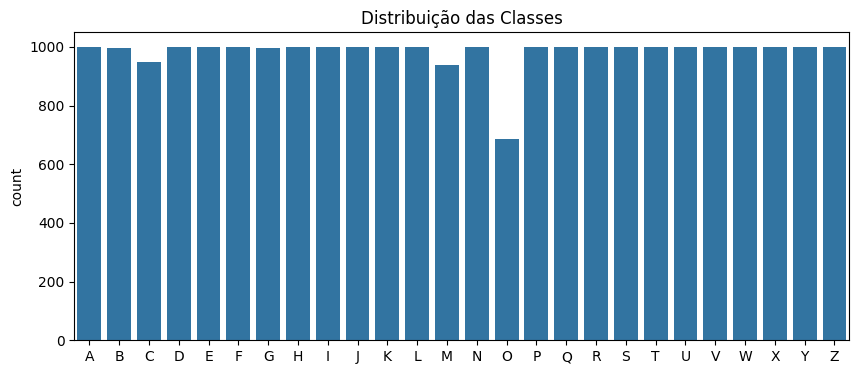

In [ ]:
# Carregar Dataset
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"O ficheiro {DATA_PATH} não foi encontrado.")

df = pd.read_csv(DATA_PATH)
print(f"Dimensões Originais: {df.shape}")

# --- LÓGICA DE CONVERSÃO (IMPORTANTE) ---
print("A converter para Coordenadas Relativas (Isto pode demorar alguns segundos)...")

X_raw = df.drop(columns=['label', 'hand'], errors='ignore').values
y_labels = df['label'].values

X_relative = []

for row in X_raw:
    # O array tem 63 valores (21 pontos * 3 coords)
    # Reshape para (21, 3) para podermos subtrair vetores
    landmarks = row.reshape(21, 3)
    
    # O Pulso é sempre o ponto 0
    wrist = landmarks[0]
    
    # Subtrair o pulso de todos os pontos
    # O pulso passa a ser (0,0,0) e os outros pontos ficam relativos a ele
    relative_landmarks = landmarks - wrist
    
    # Voltar a alisar (flatten) para array de 63 valores
    X_relative.append(relative_landmarks.flatten())

X = np.array(X_relative)
print("Conversão concluída! O dataset agora é robusto a mudanças de posição.")

# Verificar Label Balance
plt.figure(figsize=(10, 4))
sns.countplot(x=y_labels, order=sorted(np.unique(y_labels)))
plt.title('Distribuição das Classes')
plt.show()

## 2. Pré-processamento Final (Encoding, Split, Scaling)

In [10]:
# 1. Label Encoding
le = LabelEncoder()
y = le.fit_transform(y_labels)

print(f"Classes: {le.classes_}")

# 2. Divisão Treino / Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Normalização (Scaling)
# Mesmo com coordenadas relativas, o scaler ajuda modelos como SVM e MLP
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Treino Shape: {X_train_s.shape}")

Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Treino Shape: (20452, 63)


## 3. Comparação de Modelos

In [11]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

print("A avaliar modelos...")
results_data = []

for name, model in models.items():
    # Cross Validation
    cv_results = cross_validate(model, X_train_s, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    mean_acc = cv_results['test_score'].mean()
    
    results_data.append({'Model': name, 'Accuracy': mean_acc})
    print(f"-> {name}: Acc = {mean_acc:.4f}")

df_results = pd.DataFrame(results_data).sort_values(by='Accuracy', ascending=False)
display(df_results)

A avaliar modelos...
-> Random Forest: Acc = 1.0000
-> SVM: Acc = 0.9997
-> KNN: Acc = 0.9999
-> Neural Network: Acc = 0.9999


,Model,Accuracy
0,Random Forest,1.000000
3,Neural Network,0.999853
2,KNN,0.999853
1,SVM,0.999658


## 4. Otimização e Treino Final
Vamos focar no melhor modelo (geralmente SVM ou Random Forest para estes dados).

In [12]:
# Vamos usar o vencedor da lista acima. 
# Por defeito, assumimos que o SVM ou RF ganharam. Vamos otimizar o SVM como exemplo robusto.
# Se o RF for melhor, podes mudar aqui para RandomForestClassifier.

best_model_name = df_results.iloc[0]['Model']
print(f"Modelo escolhido para otimização: {best_model_name}")

if best_model_name == 'SVM':
    param_grid = {'C': [1, 10, 100], 'gamma': ['scale', 0.1, 0.01], 'kernel': ['rbf']}
    base_model = SVC(probability=True, random_state=42)
elif best_model_name == 'Random Forest':
    param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 20]}
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
else:
    # Fallback genérico
    param_grid = {}
    base_model = models[best_model_name]

# Grid Search
grid = GridSearchCV(base_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_s, y_train)

final_model = grid.best_estimator_
print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Melhor Score Treino: {grid.best_score_:.4f}")

Modelo escolhido para otimização: Random Forest
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhores parâmetros: {'max_depth': None, 'n_estimators': 100}
Melhor Score Treino: 1.0000


## 5. Avaliação Final e Matriz de Confusão

Relatório Final:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       200
           B       1.00      1.00      1.00       200
           C       1.00      1.00      1.00       189
           D       1.00      1.00      1.00       200
           E       1.00      1.00      1.00       200
           F       1.00      1.00      1.00       200
           G       1.00      1.00      1.00       200
           H       1.00      1.00      1.00       200
           I       1.00      1.00      1.00       200
           J       1.00      1.00      1.00       200
           K       1.00      1.00      1.00       200
           L       1.00      1.00      1.00       200
           M       1.00      1.00      1.00       188
           N       1.00      1.00      1.00       200
           O       1.00      1.00      1.00       137
           P       1.00      1.00      1.00       200
           Q       1.00      1.00      1.00       200
          

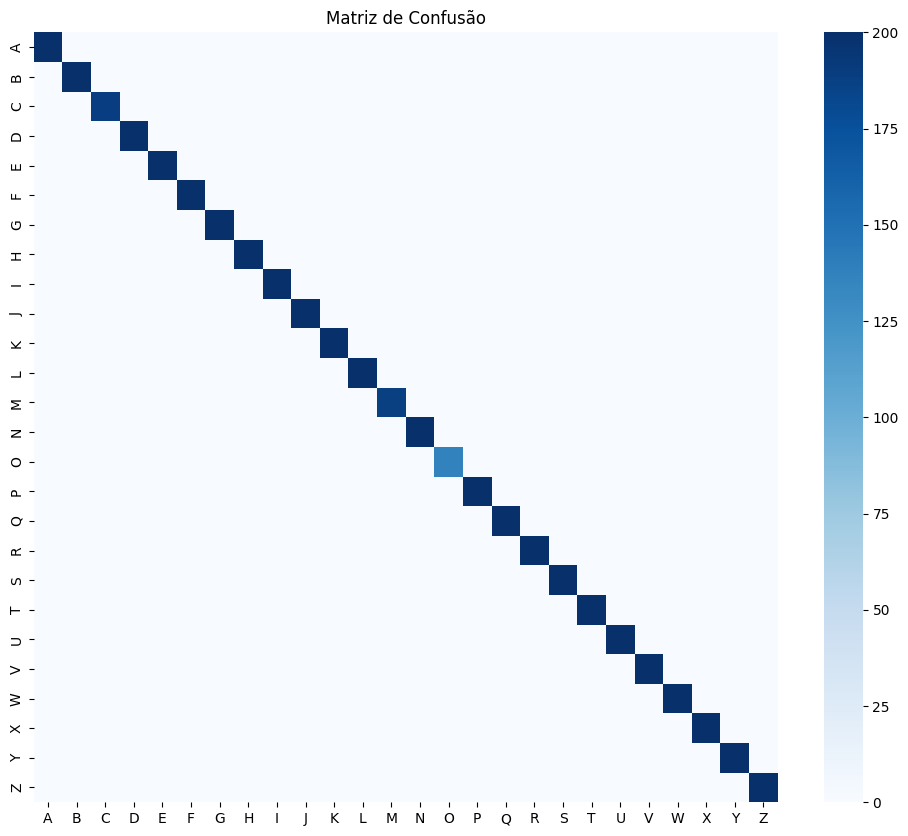

In [13]:
y_pred = final_model.predict(X_test_s)

print("Relatório Final:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão')
plt.show()

## 6. Guardar Artefactos
Estes ficheiros serão carregados pelo `app.py`.

In [ ]:
print("A guardar modelos...")

# 1. Guardar Modelo
joblib.dump(final_model, os.path.join(MODELS_DIR, 'best_model.pkl'))

# 2. Guardar Scaler (CRUCIAL para a API)
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler_hand_sign.pkl'))

# 3. Guardar Encoder
joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.pkl'))

print("Tudo guardado em 'models/'. Reinicie a API Flask agora!")

💾 A guardar modelos...
✅ Tudo guardado em 'models/'. Reinicie a API Flask agora!
